# Solving the Regge–Wheeler equation in the time domain

Linear gravitational perturbations of a Schwarzschild black hole are described by the Regge–Wheeler master equation
$$
\frac{\partial^2 \Psi\big(t,r_\star\big)}{\partial r_\star^2}
-
\frac{\partial^2 \Psi\big(t,r_\star\big)}{\partial t^2}
-
V(r)\Psi\big(t,r_\star\big)
=
S(r_\star,t),
$$
where $\Psi(t,r_\star)$ denotes the master field variable and $V(r)$ is the Regge–Wheeler potential. In this notebook, we solve this equation numerically in the time domain using localized initial perturbations introduced in `initial-data.ipynb`.

## Numerical setup and physical strategy

We perturb the black hole by specifying initial data in the form of localized Gaussian wave packets.

The goal is to analyze how the resulting waveform depends on the properties of the initial perturbation. In particular, we explore two complementary scenarios:

- Fixing the oscillation parameter $\nu = 0$ and varying the width $\sigma$
- Fixing the width $\sigma$ and varying the oscillation parameter $\nu$

This allows us to disentangle the role of spatial localization and frequency content in the excitation of the black hole response.

## Dependence on the width $\sigma$

We first consider purely Gaussian perturbations ($\nu = 0$) and vary the width parameter $\sigma = \{1, 5, 9\}$.

Physically, $\sigma$ controls the spatial localization of the perturbation:

- Small $\sigma$ → highly localized pulse → broad frequency content  
- Large $\sigma$ → extended perturbation → narrow frequency content  

We expect this to directly impact the excitation of quasi-normal modes and the overall structure of the waveform.

In [1]:
import rw_solver as rw
import numpy as np
import matplotlib.pyplot as plt

### $\sigma=1$

In [2]:
Psi0_s1 = rw.gaussiana(1, -200, 1000, 8000, 0.0, 100.0, 1)

U_s1, T_s1, s_s1 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_s1,
    TF=700
)

Psi_obs_s1 = rw.extract_observer_4th(U_s1, s_s1, 100.0)

### $\sigma=5$

In [3]:
Psi0_s5 = rw.gaussiana(1, -200, 1000, 8000, 0.0, 100.0, 5)

U_s5, T_s5, s_s5 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_s5,
    TF=700
)

Psi_obs_s5 = rw.extract_observer_4th(U_s5, s_s5, 100.0)

### $\sigma=9$

In [4]:
Psi0_s9 = rw.gaussiana(1, -200, 1000, 8000, 0.0, 100.0, 9)

U_s9, T_s9, s_s9 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_s9,
    TF=700
)

Psi_obs_s9 = rw.extract_observer_4th(U_s9, s_s9, 100.0)

The waveform is extracted at a fixed observer location $r_\star^{\mathrm{obs}} = 100$.

We represent the absolute value of the signal in logarithmic scale in order to clearly visualize the different phases of the evolution, including prompt response, ringdown and late-time decay.

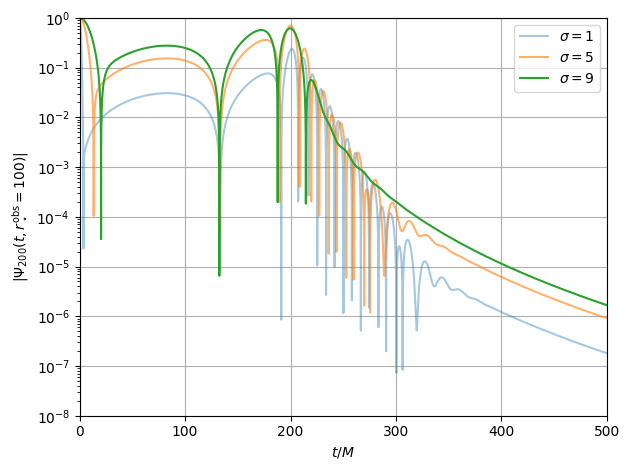

In [5]:
plt.figure()

plt.plot(T_s1, np.abs(Psi_obs_s1),  ls='-', alpha=0.4, label=r"$\sigma=1$")
plt.plot(T_s5, np.abs(Psi_obs_s5),  ls='-', alpha=0.6, label=r"$\sigma=5$")
plt.plot(T_s9, np.abs(Psi_obs_s9),  ls='-', alpha=1.0, label=r"$\sigma=9$")

plt.yscale("log")
plt.xlim(0,500)
plt.ylim(1e-8,1)
plt.xlabel(r"$t/M$")
plt.ylabel(r"$|\Psi_{200}(t,r_\star^{\mathrm{obs}}=100)|$")
plt.grid(True)
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

## Dependence on the oscillation parameter $\nu$

We now consider oscillatory Gaussian perturbations with fixed width $\sigma = 5$, while varying the parameter
$$
\nu = \{0.185, 0.373, 0.555\}.
$$

The parameter $\nu$ introduces a preferred frequency scale in the initial data. As shown in the previous notebook, this translates into a spectral distribution peaked around $\omega \sim \pm \nu$.

This setup allows us to probe how efficiently different frequency components couple to the black hole's quasi-normal spectrum.

### $\nu = 0.185$

In [6]:
Psi0_w0185 = rw.gaussiana(1, -200, 1000, 8000, 0.185, 100.0, 5)

U_w0185, T_w0185, s_w0185 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_w0185,
    TF=700
)

Psi_w0185 = rw.extract_observer_4th(U_w0185, s_w0185, 100.0)

### $\nu = 0.373$

In [7]:
Psi0_w0373 = rw.gaussiana(1, -200, 1000, 8000, 0.373, 100.0, 5)

U_w0373, T_w0373, s_w0373 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_w0373,
    TF=700
)

Psi_w0373 = rw.extract_observer_4th(U_w0373, s_w0373, 100.0)

### $\nu = 0.555$

In [8]:
Psi0_w0555 = rw.gaussiana(1, -200, 1000, 8000, 0.555, 100.0, 5)

U_w0555, T_w0555, s_w0555 = rw.simula_full(
    N=8000,
    x_min=-200,
    x_max=1000,
    Psi_initial=Psi0_w0555,
    TF=700
)

Psi_w0555 = rw.extract_observer_4th(U_w0555, s_w0555, 100.0)

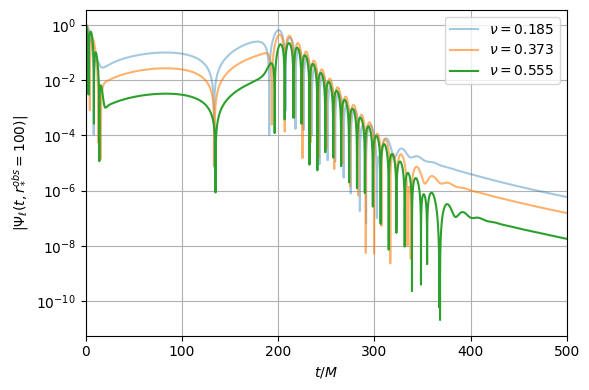

In [9]:
plt.figure(figsize=(6,4))

plt.plot(T_w0185, np.abs(Psi_w0185), alpha=0.4, label=r"$\nu=0.185$")
plt.plot(T_w0373, np.abs(Psi_w0373), alpha=0.6, label=r"$\nu=0.373$")
plt.plot(T_w0555, np.abs(Psi_w0555), alpha=1.0, label=r"$\nu=0.555$")

plt.yscale("log")
plt.xlim(0,500)
plt.xlabel(r"$t/M$")
plt.ylabel(r"$|\Psi_\ell(t, r_*^{obs}=100)|$")
plt.grid()
plt.legend(frameon=True)

plt.tight_layout()
plt.show()

These experiments illustrate two key aspects of black hole perturbations:

- The width $\sigma$ controls the *spectral spread* of the initial perturbation  
- The parameter $\nu$ selects *which frequency bands are predominantly excited*  

Together, they determine how the initial perturbation projects onto the quasi-normal mode spectrum of the black hole.